In [4]:
from moviepy.editor import VideoClip
import numpy as np

# Generate frames function
def make_frame(t):
    import matplotlib.pyplot as plt
    from io import BytesIO
    fig, ax = plt.subplots()
    x = np.linspace(0, 2*np.pi, 200)
    y = np.sin(x + t)
    ax.plot(x, y)
    ax.set_ylim(-1, 1)
    buf = BytesIO()
    plt.savefig(buf, format='png')
    plt.close(fig)
    buf.seek(0)
    import cv2
    import numpy as np
    frame = cv2.imdecode(np.frombuffer(buf.read(), np.uint8), 1)
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

clip = VideoClip(make_frame, duration=5)  # 5 seconds
clip.write_videofile("sine_animation.mp4", fps=20)


ModuleNotFoundError: No module named 'moviepy.editor'

MovieWriter Pillow unavailable; using Pillow instead.


ValueError: unknown file extension: .mp4

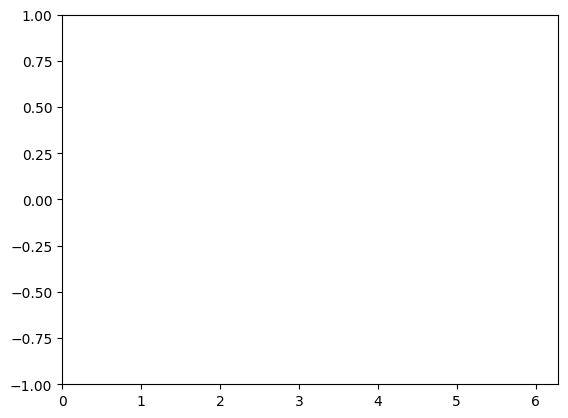

In [11]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np

# Data
x = np.linspace(0, 2*np.pi, 200)
y = np.sin(x)

fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2)

ax.set_xlim(0, 2*np.pi)
ax.set_ylim(-1, 1)

def animate(i):
    line.set_data(x[:i], y[:i])
    return line,

ani = FuncAnimation(fig, animate, frames=len(x), interval=20)
ani.save("sine_wave.mp4", writer="Pillow")  # save as mp4


In [6]:
import cv2
import glob

img_array = []
for filename in sorted(glob.glob('images/*.png')):
    img = cv2.imread(filename)
    height, width, layers = img.shape
    size = (width,height)
    img_array.append(img)

out = cv2.VideoWriter('output_video.avi', cv2.VideoWriter_fourcc(*'DIVX'), 10, size)

for i in range(len(img_array)):
    out.write(img_array[i])
out.release()



ModuleNotFoundError: No module named 'cv2'

                                  title  imdb_score
0   Five Came Back: The Reference Films         NaN
1                           Taxi Driver         8.2
2                           Deliverance         7.7
3       Monty Python and the Holy Grail         8.2
4                       The Dirty Dozen         7.7
5          Monty Python's Flying Circus         8.8
6                         Life of Brian         8.0
7                           Dirty Harry         7.7
8                      Bonnie and Clyde         7.7
9                       The Blue Lagoon         5.8
10                 The Guns of Navarone         7.5
11                    The Professionals         7.3
12       Richard Pryor: Live in Concert         8.1
13                      White Christmas         7.5
14                        Cairo Station         7.5
15                     Hitler: A Career         7.5
16                                  FTA         6.2
17                     Alexandria… Why?         7.2
18          

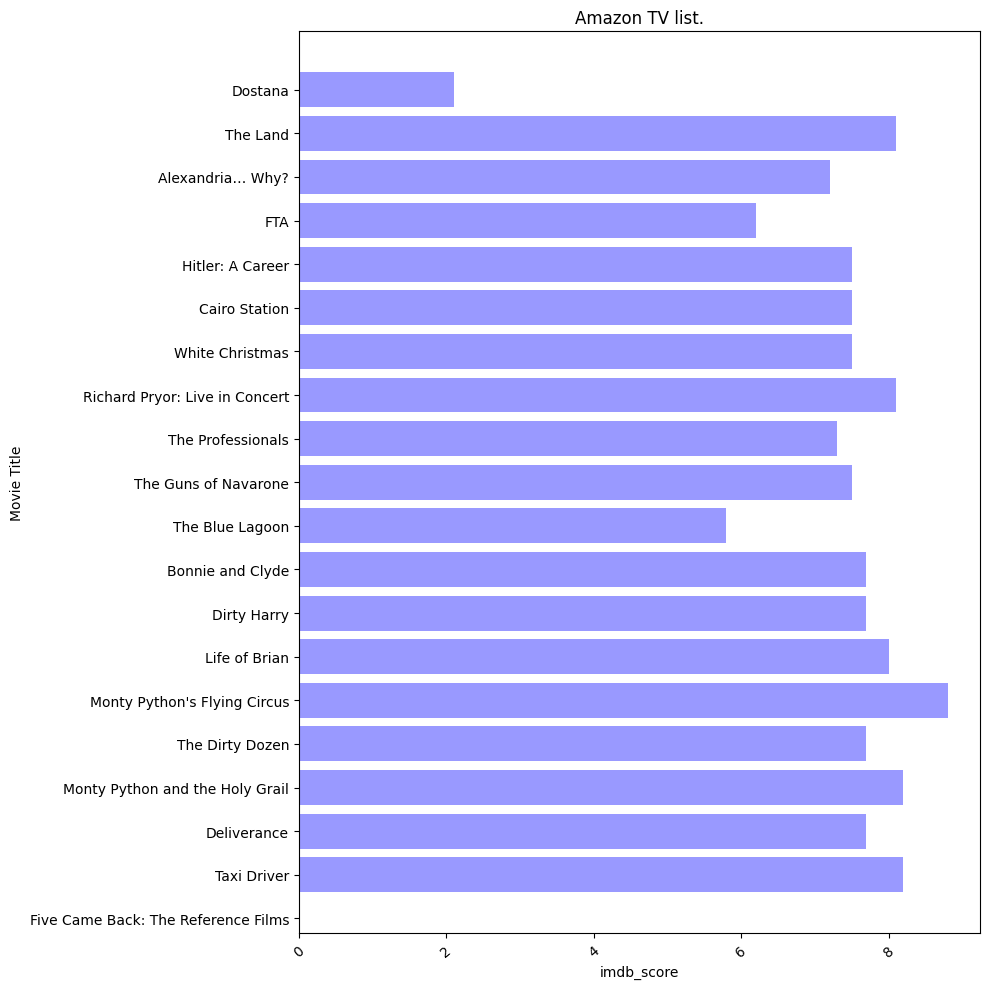

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# df0=pd.read_excel(r"C:\Users\Uthoaingyo\Python\Movie.xlsx",)
df0=pd.read_csv(r'C:\Users\Uthoaingyo\AppData\Local\Temp\cbd6e5fa-02dc-42cf-acfb-0c25bd30a493_archive.zip.493\titles.csv')

df=df0.head(20)
pd.DataFrame(df)
# df_filter=df[]
print(df[['title','imdb_score']])

plt.figure(figsize=(10,10))
plt.barh(df['title'],df['imdb_score'],color='blue',alpha=0.4)
plt.xlabel('imdb_score')
plt.ylabel('Movie Title')
plt.title('Amazon TV list.')
plt.xticks(rotation=40)
plt.tight_layout()
plt.show()

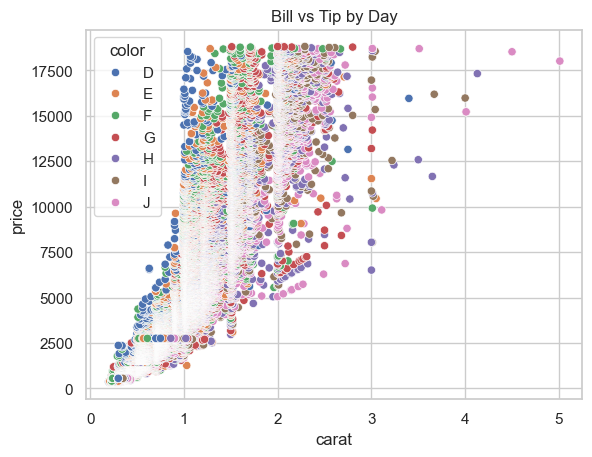

<bound method DataFrame.info of        carat        cut color clarity  depth  table  price     x     y     z
0       0.23      Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1       0.21    Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2       0.23       Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3       0.29    Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4       0.31       Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
...      ...        ...   ...     ...    ...    ...    ...   ...   ...   ...
53935   0.72      Ideal     D     SI1   60.8   57.0   2757  5.75  5.76  3.50
53936   0.72       Good     D     SI1   63.1   55.0   2757  5.69  5.75  3.61
53937   0.70  Very Good     D     SI1   62.8   60.0   2757  5.66  5.68  3.56
53938   0.86    Premium     H     SI2   61.0   58.0   2757  6.15  6.12  3.74
53939   0.75      Ideal     D     SI2   62.2   55.0   2757  5.83  5.87  3.64

[53940 rows x 10 columns]>


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset("diamonds")

# সহজ Scatter Plot
sns.scatterplot(data=df, x="carat", y="price", hue="color")
# Histogram with KDE curve
# sns.histplot(data=df, x="total_bill", kde=True, color="purple")
# plt.show()
plt.title("Bill vs Tip by Day")
plt.show()
print(df.info)

C:\Users\Uthoaingyo\AppData\Local\Temp\ipykernel_22288\3409152712.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


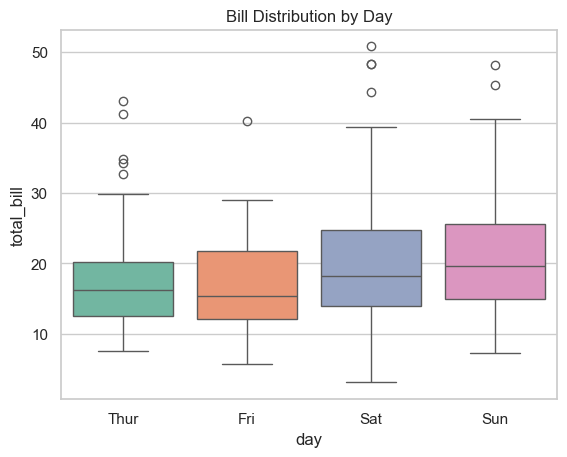

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn built-in dataset load
df = sns.load_dataset("tips")

# Style সেট করা (optional কিন্তু সুন্দর হয়)
sns.set(style="whitegrid")

# Box Plot: Day অনুযায়ী Total Bill distribution
sns.boxplot(
    data=df,
    x="day",
    y="total_bill",
    palette="Set2"
)

# Title যোগ করা
plt.title("Bill Distribution by Day")

# Plot দেখানো
plt.show()

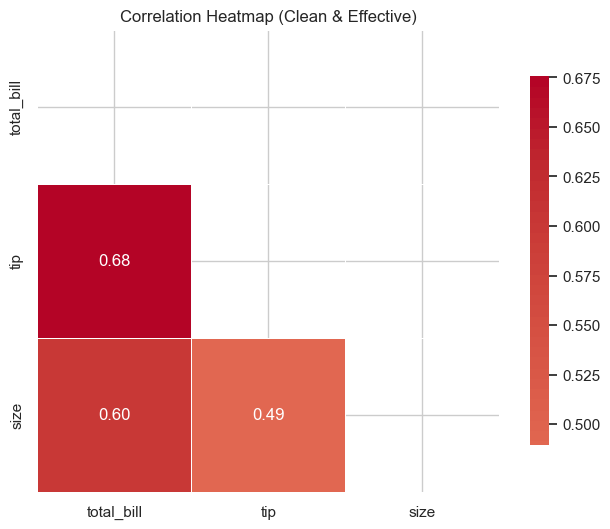

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Numeric columns নিয়ে correlation
corr = df.select_dtypes(include="number").corr()

# Upper triangle mask
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap (Clean & Effective)")
plt.show()

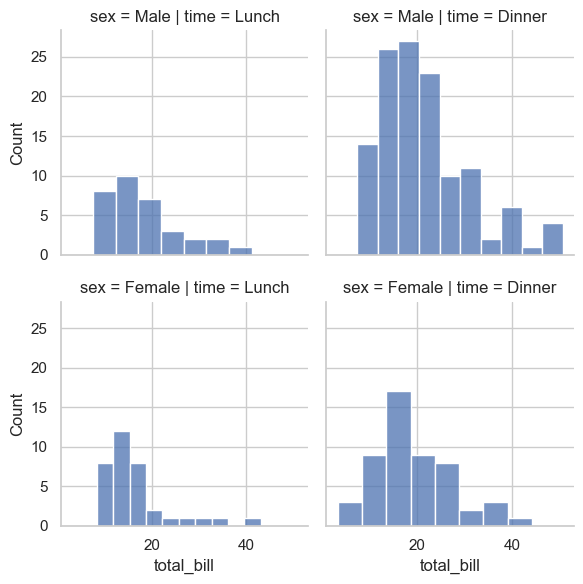

In [ ]:
# সময় (Lunch/Dinner) এবং লিঙ্গ অনুযায়ী আলাদা আলাদা গ্রাফ   //multiple grid
g = sns.FacetGrid(df, col="time", row="sex")
g.map(sns.histplot, "total_bill")
plt.show()

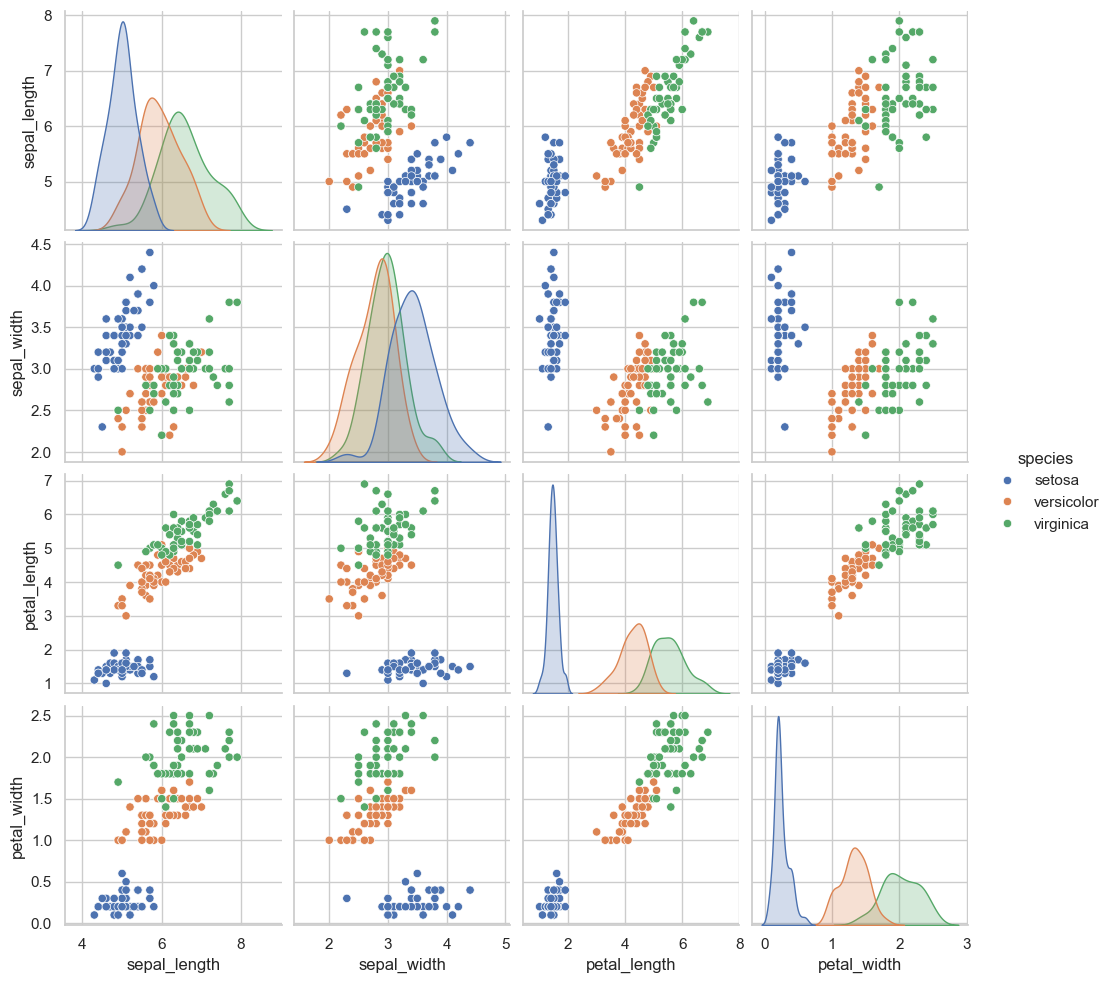

In [ ]:
iris = sns.load_dataset("iris")

# পুরো ডেটাসেটের একটা ওভারভিউ
sns.pairplot(iris, hue="species", diag_kind="kde")
plt.show()